In [1]:
"""
Burst_simulation_analysis.ipynb
Lukasz Radzinski
Charité Neurophysics Group, Berlin
Script for analysis of sigma burst
simulation results
"""

'\nBurst_simulation_analysis.ipynb\nLukasz Radzinski\nCharité Neurophysics Group, Berlin\nScript for analysis of sigma burst\nsimulation results\n'

In [2]:
import os
import meet
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig
from BurstModel import BurstModel
import matplotlib.ticker as plticker


# set global parameters for plots

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600

2026-04-07 22:56:06.453912: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 22:56:06.475626: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# general settings

# select subject [S1-S5]
subject = 'S1'

additional_file_info = ''
additional_title_info = ''

data_input_folder = '../Data/cleaned_data'
plots_output_folder = '../Results/burst_simulation_analysis'

additional_plot_title = ''

srate = 20000

meg_unit = 'B [fT]'
meg_asd_unit = '[fT/√Hz]'

In [4]:
# add header to the plot
def plt_header(main_title='', use_suptitle = False, fontsize=12):

    title = main_title
    
    if(use_suptitle):
        plt.suptitle(title, fontsize=fontsize)
    else:
        plt.title(title, fontsize=fontsize)

In [5]:
# show and save the plot
def plt_show_save_fig(fig_name=None):

    if(fig_name):
        fig_name += '.png'
    else:
        plt_show_save_fig.counter += 1
        fig_name = 'fig%02d.png' % plt_show_save_fig.counter

    print('--------------------\n'+fig_name)
    os.makedirs(plots_output_folder, exist_ok=True)
    plt.savefig(os.path.join(plots_output_folder, fig_name), bbox_inches='tight')
    plt.show()

plt_show_save_fig.counter = 0

In [6]:
# load MEG and marker data

meg_data_file = os.path.join(data_input_folder, subject+'.npy')
meg_stim_data = np.load(meg_data_file)

meg_data = meg_stim_data[0]
marker = meet.getMarker(meg_stim_data[-1])

In [7]:
# generate percentile sorting mask
def percentile_sorting_mask(percentiled_signal, percentile_bin=10):

    trials_percentile_range = np.arange(0, 100, percentile_bin)
    trials_percentile_bins_names = []
    trials_percentile_list = []

    for i in trials_percentile_range:
        trials_percentile_list.append(scipy.stats.scoreatpercentile(percentiled_signal, i))

    trials_percentile_list[0] = -np.inf
    trials_percentile_list.append(np.inf)
    trials_percentile_range = np.append(trials_percentile_range, 100)

    for i in range(len(trials_percentile_range)-1):
        trials_percentile_bins_names.append('%s-%s' % (trials_percentile_range[i], trials_percentile_range[i+1]))
    
    percentile_mask_list = []

    for i in range(len(trials_percentile_list)-1):
        percentile_mask = (percentiled_signal > trials_percentile_list[i]) * (percentiled_signal <= trials_percentile_list[i+1])
        percentile_mask_list.append(percentile_mask)
    
    return percentile_mask_list, trials_percentile_bins_names

In [8]:
burst_prop_df = pd.read_csv('burst_subjects.csv')

lfreq_sigma = burst_prop_df[burst_prop_df['Subject']==subject]['Freq_start'].values[0]
rfreq_sigma = burst_prop_df[burst_prop_df['Subject']==subject]['Freq_end'].values[0]

sigma_freq_range = [lfreq_sigma, rfreq_sigma]

burst_time_start = burst_prop_df[burst_prop_df['Subject']==subject]['Time_start'].values[0]
burst_time_end = burst_prop_df[burst_prop_df['Subject']==subject]['Time_end'].values[0]

burst_win_ms = [burst_time_start, burst_time_end]

In [9]:
meg_data_hilb = sig.hilbert(meg_data)

# FIR filter
# apply band-pass filter to extract
# high-frequency band (sigma band)
# extend the band ±50Hz to obtain
# 3dB cutoff in the bandstop frequencies
sigma_fir_coeffs = sig.firwin(303, [lfreq_sigma-50, rfreq_sigma+50], pass_zero=False, fs=srate)
meg_sigma_data = sig.filtfilt(sigma_fir_coeffs, 1.0, meg_data_hilb)

In [10]:
short_win_ms = [10,35]
short_win_samples = np.round(np.array(short_win_ms)/1000.*srate).astype(int)

medium_win_ms = [-20,120]
medium_win_samples = np.round(np.array(medium_win_ms)/1000.*srate).astype(int)

burst_win_samples = np.round(np.array(burst_win_ms)/1000.*srate).astype(int)
sigma_burst_trials = meet.epochEEG(meg_sigma_data, marker, burst_win_samples)
data_t_burst_ms = np.linspace(burst_win_ms[0], burst_win_ms[1], sigma_burst_trials.shape[-2]+1)[:-1]

sigma_short_trials = meet.epochEEG(meg_sigma_data, marker, short_win_samples)
sigma_medium_trials = meet.epochEEG(meg_sigma_data, marker, medium_win_samples)

data_t_short_ms = np.linspace(short_win_ms[0], short_win_ms[1], sigma_short_trials.shape[-2]+1)[:-1]
data_t_medium_ms = np.linspace(medium_win_ms[0], medium_win_ms[1], sigma_medium_trials.shape[-2]+1)[:-1]

In [11]:
# calculate indices in medium trials that correspond to the sigma burst time window

burst_mt_smpl = [np.nonzero(data_t_medium_ms == burst_win_ms[0])[0][0],
              np.nonzero(data_t_medium_ms == burst_win_ms[1])[0][0]]
burst_mt_smpl = np.array(burst_mt_smpl)

# set simulated burst offset position in relation the physiological burst
sigma_sim_offset_ms = 30
burst_sim_mt_smpl = np.array(burst_mt_smpl)+sigma_sim_offset_ms*srate//1000
data_t_burst_sim_ms = data_t_burst_ms + sigma_sim_offset_ms

In [12]:
model_variables_subj = {}

model_variables_subj['S1'] = [1.394, 0.322, 0.000, 0.000, 0.519, 2.777] 
model_variables_subj['S2'] = [2.163, 0.326, 0.000, 0.000, 0.252, 1.396]
model_variables_subj['S3'] = [0.640, 0.385, 0.000, 0.000, 0.366, 2.031]
model_variables_subj['S4'] = [0.818, 0.354, 0.000, 0.000, 0.483, 2.140]
model_variables_subj['S5'] = [0.510, 0.402, 0.000, 0.000, 0.667, 2.354]

model_variables = model_variables_subj[subject]
[div_steep, div_pos, ecavs, eclvs, lcavs, lclvs] = model_variables
div_pos_ms = div_pos*(burst_win_ms[1]-burst_win_ms[0])+burst_win_ms[0]

In [13]:
bm = BurstModel(data_t_medium_ms, sigma_medium_trials, burst_win_ms, sigma_sim_offset_ms, srate, seed=60)

[loss, division_curve, later_comp_sigma_er, lcabs, earlier_comp_sigma_er, ecabs, sigma_bursts_sim,
sigma_sim_medium_trials] = [i.numpy() for i in bm.calculate_model_output(model_variables)]

model_out_static = bm.calculate_model_output([10,0,0,0,0,0])
sigma_stat_medium_trials = model_out_static[-1].numpy()
evoked_response = model_out_static[2].numpy()

In [14]:
print('ecabs: ', ecabs)
print('lcabs: ', lcabs)

ecabs:  0.9999999999999989
lcabs:  1.156190939149872


--------------------
fig01.png


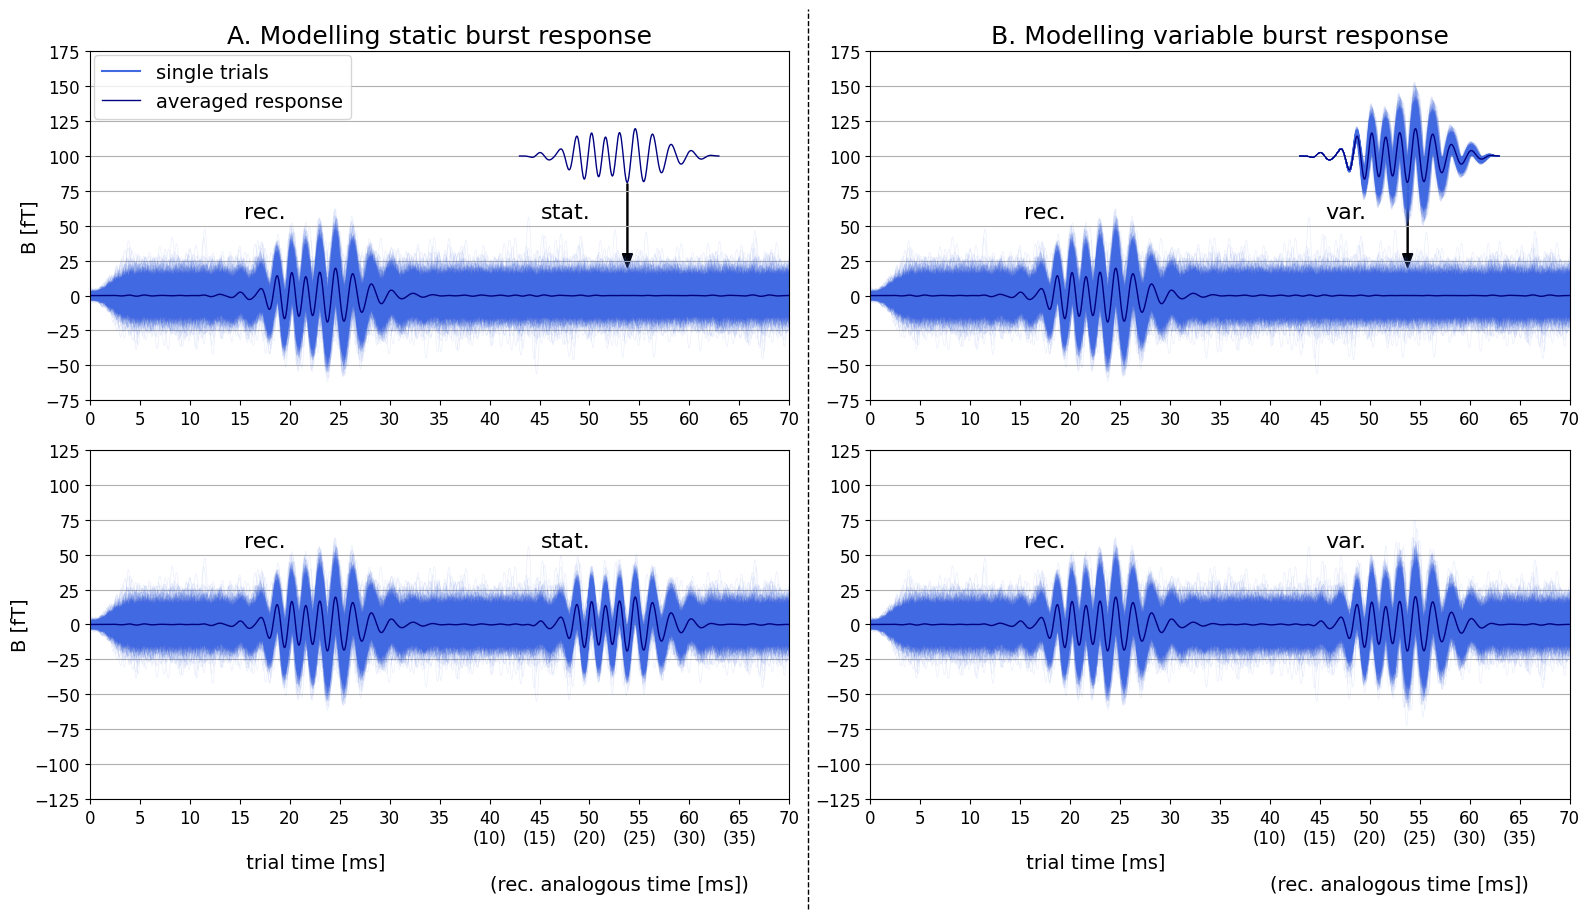

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(16, 9))

data_y = sigma_medium_trials.real
data_t = data_t_medium_ms

t_ticks = np.arange(0, 75, 5)
t_ticks_labels = t_ticks.astype('str')
t_ticks_labels[8:14] = ['40\n(10)', '45\n(15)', '50\n(20)', '55\n(25)', '60\n(30)', '65\n(35)']


i,j = 0,0

axs[i][j].set_title('A. Modelling static burst response', fontsize = 18)
axs[i][j].plot(data_t, data_y, color='royalblue', alpha=0.1, linewidth=0.5)
axs[i][j].plot([], [], color='royalblue', label='single trials')
axs[i][j].plot(data_t, data_y.mean(-1), color='navy', linewidth=1)
axs[i][j].plot(data_t_burst_sim_ms, evoked_response.real+100, color='navy', linewidth=1, label='averaged response')
axs[i][j].arrow(53.8, 80, 0, -60, length_includes_head=True, width=0.1, head_width=1, head_length=10, color='black')
axs[i][j].set_xlim(0, 70)
axs[i][j].get_xaxis().set_major_locator(plticker.MultipleLocator(5))
axs[i][j].get_yaxis().set_major_locator(plticker.MultipleLocator(25))
axs[i][j].set_ylim(-75, 175)
axs[i][j].grid(axis='y')
axs[i][j].set_ylabel(meg_unit, size=14)
axs[i][j].tick_params(axis='y', labelsize=12)
axs[i][j].tick_params(axis='x', labelsize=12)
axs[i][j].text(0.25, 0.54, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)
axs[i][j].text(0.68, 0.54, 'stat.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)
axs[i][j].legend(loc='upper left', borderaxespad=0.2, fontsize=14)


i,j = 0,1

axs[i][j].set_title('B. Modelling variable burst response', fontsize = 18)
axs[i][j].plot(data_t, data_y, color='royalblue', alpha=0.1, linewidth=0.5)
axs[i][j].plot(data_t, data_y.mean(-1), color='navy', linewidth=1)
axs[i][j].plot(data_t_burst_sim_ms, sigma_bursts_sim.real+100, color='royalblue', alpha=0.1, linewidth=0.5)
axs[i][j].plot(data_t_burst_sim_ms, evoked_response.real+100, color='navy', linewidth=1)
axs[i][j].arrow(53.8, 80, 0, -60, length_includes_head=True, width=0.1, head_width=1, head_length=10, color='black')
axs[i][j].set_xlim(0, 70)
axs[i][j].get_xaxis().set_major_locator(plticker.MultipleLocator(5))
axs[i][j].get_yaxis().set_major_locator(plticker.MultipleLocator(25))
axs[i][j].set_ylim(-75, 175)
axs[i][j].grid(axis='y')
axs[i][j].tick_params(axis='y', labelsize=12)
axs[i][j].tick_params(axis='x', labelsize=12)
axs[i][j].text(0.25, 0.54, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)
axs[i][j].text(0.68, 0.54, 'var.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)


data_y = sigma_stat_medium_trials.real
data_t = data_t_medium_ms

i,j = 1,0

axs[i][j].plot(data_t, data_y, color='royalblue', alpha=0.1, linewidth=0.5)
axs[i][j].plot(data_t, data_y.mean(-1), color='navy', linewidth=1)
axs[i][j].set_xlim(0, 70)
axs[i][j].get_xaxis().set_major_locator(plticker.MultipleLocator(5))
axs[i][j].get_yaxis().set_major_locator(plticker.MultipleLocator(25))
axs[i][j].set_ylim(-125, 125)
axs[i][j].grid(axis='y')
axs[i][j].set_ylabel(meg_unit, size=14)
axs[i][j].set_xticks(t_ticks, labels=t_ticks_labels)
axs[i][j].set_xlabel('                         trial time [ms]\n'
'                                                                (rec. analogous time [ms])',
                                                              loc='left', fontsize=14)
axs[i][j].tick_params(axis='y', labelsize=12)
axs[i][j].tick_params(axis='x', labelsize=12)
axs[i][j].text(0.25, 0.74, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)
axs[i][j].text(0.68, 0.74, 'stat.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)


data_y = sigma_sim_medium_trials.real
data_t = data_t_medium_ms

i,j = 1,1

axs[i][j].plot(data_t, data_y, color='royalblue', alpha=0.1, linewidth=0.5)
axs[i][j].plot(data_t, data_y.mean(-1), color='navy', linewidth=1)
axs[i][j].set_xlim(0, 70)
axs[i][j].get_xaxis().set_major_locator(plticker.MultipleLocator(5))
axs[i][j].get_yaxis().set_major_locator(plticker.MultipleLocator(25))
axs[i][j].set_ylim(-125, 125)
axs[i][j].grid(axis='y')
axs[i][j].set_xticks(t_ticks, labels=t_ticks_labels)
axs[i][j].set_xlabel('                         trial time [ms]\n'
'                                                                (rec. analogous time [ms])',
                                                              loc='left', fontsize=14)
axs[i][j].tick_params(axis='y', labelsize=12)
axs[i][j].tick_params(axis='x', labelsize=12)
axs[i][j].text(0.25, 0.74, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)
axs[i][j].text(0.68, 0.74, 'var.', fontsize=16, ha='center', va='center', transform=axs[i][j].transAxes)

fig.lines.append(
    plt.Line2D(
        (0.508, 0.508),
        (0, 1),
        transform=fig.transFigure,
        color='black',
        linestyle='--',
        linewidth=1
    )
)

fig.tight_layout()
plt_show_save_fig()

--------------------
fig02.png


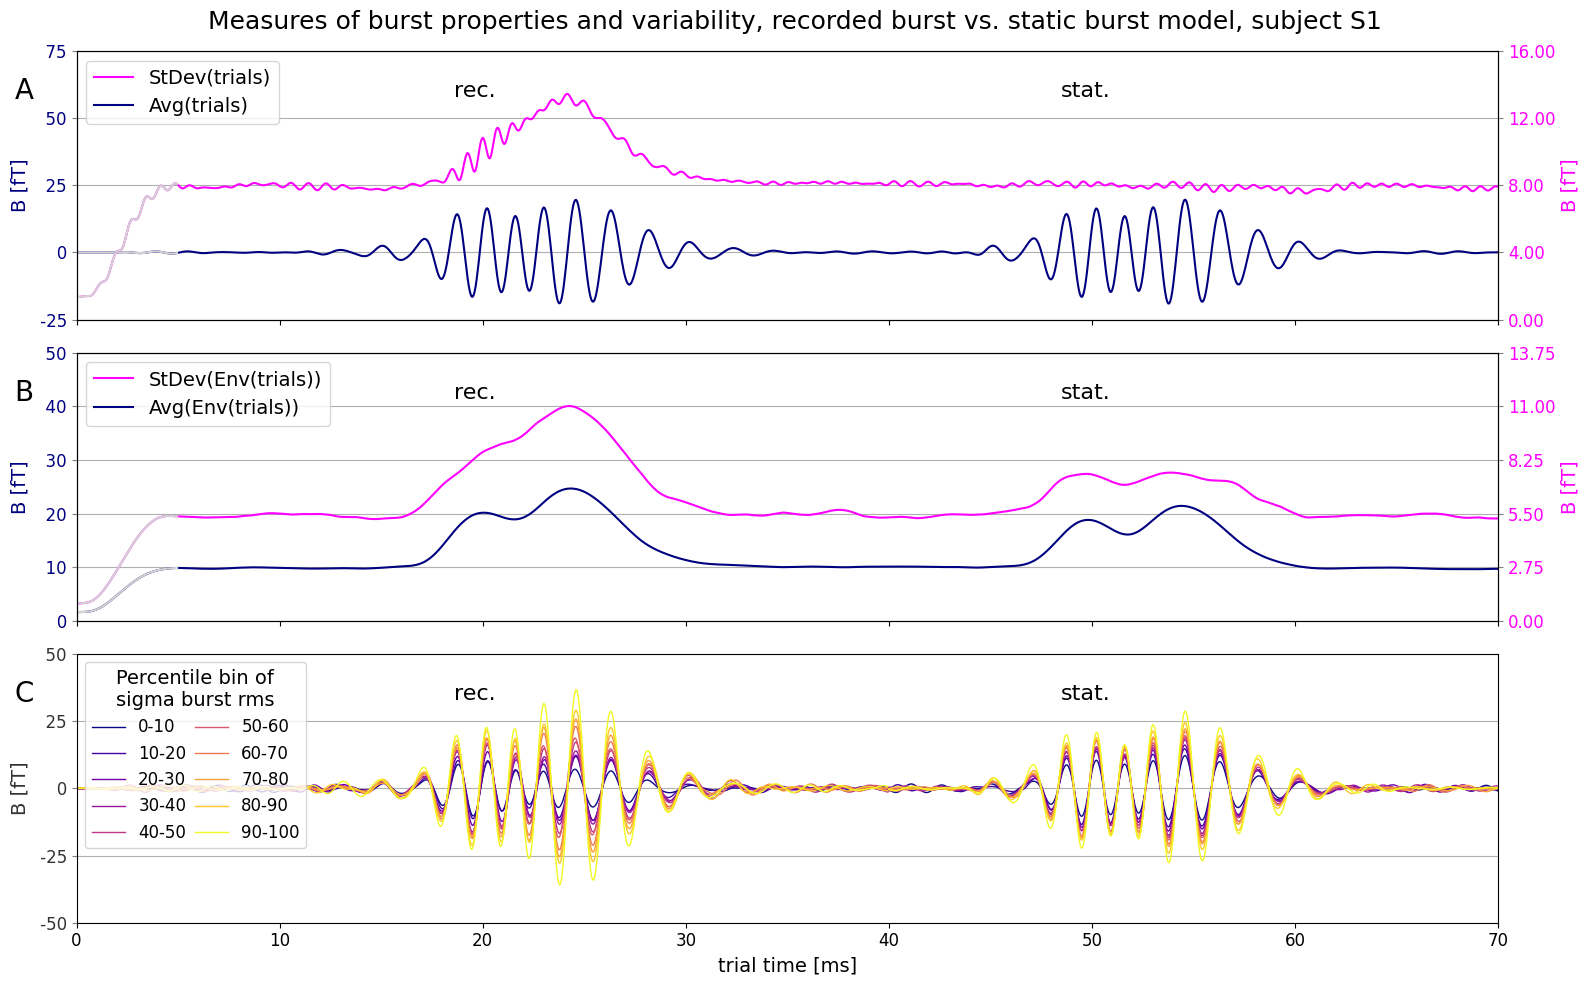

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(16, 10))

plt_header('Measures of burst properties and variability, recorded burst vs. static burst model, subject %s'
           % subject, use_suptitle=True, fontsize=18)

data_t = data_t_medium_ms
data_y = sigma_stat_medium_trials.real.mean(-1)
axs[0].plot([], label='StDev(trials)', color='magenta')
axs[0].plot(data_t, data_y, label='Avg(trials)', color='navy')
axs[0].plot(data_t[:500], data_y[:500], color='lightgray')
axs[0].set_xlim(0, 70)
axs[0].tick_params(axis='x', labelbottom=False)
axs[0].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[0].set_ylim(-25, 75)
axs[0].grid(axis='y')
axs[0].yaxis.set_major_locator(plticker.MultipleLocator(25))
axs[0].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[0].tick_params(axis='y', color='grey', labelcolor='navy', labelsize=12)
axs[0].set_ylabel(meg_unit, color='navy', fontsize=14)
axs[0].legend(loc='upper left', fontsize=14)

axs2 = axs[0].twinx()
data_y = sigma_stat_medium_trials.real.std(-1)
std_baseline = np.round(data_y[-500:].mean()*2)/2
axs2.plot(data_t, data_y, color='magenta')
axs2.plot(data_t[:500], data_y[:500], color='lightgray')
ts = std_baseline/2
yticks = [0, ts, 2*ts, 3*ts, 4*ts]
axs2.set_ylim((yticks[0], yticks[-1]))
axs2.set_yticks(yticks) 
axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.2f'))
axs2.tick_params(axis='y', color='grey', labelcolor='magenta', labelsize=12)
axs2.set_ylabel(meg_unit, color='magenta', fontsize=14)

data_y = sigma_stat_medium_trials.__abs__().mean(-1)
axs[1].plot([], label='StDev(Env(trials))', color='magenta')
axs[1].plot(data_t, data_y, label='Avg(Env(trials))', color='navy')
axs[1].plot(data_t[:500], data_y[:500], color='lightgray')
axs[1].set_xlim(0, 70)
axs[1].tick_params(axis='x', labelbottom=False)
axs[1].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[1].set_ylim(0, 50)
axs[1].grid(axis='y')
axs[1].yaxis.set_major_locator(plticker.MultipleLocator(10))
axs[1].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[1].tick_params(axis='y', color='grey', labelcolor='navy', labelsize=12)
axs[1].set_ylabel(meg_unit, color='navy', fontsize=14)
axs[1].legend(loc='upper left', fontsize=14)

axs2 = axs[1].twinx()
data_y = sigma_stat_medium_trials.__abs__().std(-1)
std_baseline = np.round(data_y[-500:].mean()*2)/2
axs2.plot(data_t, data_y, color='magenta')
axs2.plot(data_t[:500], data_y[:500], color='lightgray')
ts = std_baseline/2
yticks = [0, ts, 2*ts, 3*ts, 4*ts, 5*ts]
axs2.set_ylim((yticks[0], yticks[-1]))
axs2.set_yticks(yticks) 
axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.2f'))
axs2.tick_params(axis='y', color='grey', labelcolor='magenta', labelsize=12)
axs2.set_ylabel(meg_unit, color='magenta', fontsize=14)


data = sigma_stat_medium_trials.real

sigma_trials_rms = np.sqrt(
    np.mean(data[burst_mt_smpl[0]:burst_mt_smpl[1]].real**2, axis=-2))

percentiled_signal = sigma_trials_rms
percentile_mask_list, trials_percentile_bins_names = percentile_sorting_mask(percentiled_signal)

I_mt_smpl = [0, np.nonzero(data_t_medium_ms == 40)[0][0]]
I_mt_smpl = np.array(I_mt_smpl)


colors = plt.cm.plasma(np.linspace(0, 1, len(percentile_mask_list)))
for k in range(len(percentile_mask_list)):
    data_y = data[:,percentile_mask_list[k]]
    data_y = np.mean(data_y, axis=-1)
    axs[2].plot(data_t[I_mt_smpl[0]:I_mt_smpl[1]], data_y[I_mt_smpl[0]:I_mt_smpl[1]],
                color=colors[k], label=trials_percentile_bins_names[k], linewidth=1)

sigma_stat_trials_rms = np.sqrt(
    np.mean(data[burst_sim_mt_smpl[0]:burst_sim_mt_smpl[1]].real**2, axis=-2))

percentiled_signal = sigma_stat_trials_rms
percentile_mask_list, trials_percentile_bins_names = percentile_sorting_mask(percentiled_signal)

II_mt_smpl = [np.nonzero(data_t_medium_ms == 40)[0][0], np.nonzero(data_t_medium_ms == 80)[0][0]]
II_mt_smpl = np.array(II_mt_smpl)


colors = plt.cm.plasma(np.linspace(0, 1, len(percentile_mask_list)))
for k in range(len(percentile_mask_list)):
    data_y = data[:,percentile_mask_list[k]]
    data_y = np.mean(data_y, axis=-1)
    axs[2].plot(data_t[II_mt_smpl[0]:II_mt_smpl[1]], data_y[II_mt_smpl[0]:II_mt_smpl[1]],
                color=colors[k], linewidth=1)

axs[2].set_xlim(0, 70)
axs[2].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[2].set_ylim(-50, 50)
axs[2].grid(axis='y')
axs[2].yaxis.set_major_locator(plticker.MultipleLocator(25))
axs[2].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[2].tick_params(axis='y', color='grey', labelcolor='0.2', labelsize=12)
axs[2].set_ylabel('B [fT]', color='0.2',fontsize=14)
axs[2].legend(title='Percentile bin of\nsigma burst rms', ncol=2, columnspacing=0.5, loc='upper left',
              title_fontsize=14, fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].set_xlabel('trial time [ms]', fontsize=14)

for i in range(3):
    axs[i].text(0.28, 0.85, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i].transAxes)

    axs[i].text(0.71, 0.85, 'stat.', fontsize=16, ha='center', va='center', transform=axs[i].transAxes)

axs[0].text(-0.037, 0.85, 'A', fontsize=20,
            ha='center', va='center', transform=axs[0].transAxes)
axs[1].text(-0.037, 0.85, 'B', fontsize=20,
            ha='center', va='center', transform=axs[1].transAxes)
axs[2].text(-0.037, 0.85, 'C', fontsize=20,
            ha='center', va='center', transform=axs[2].transAxes)

fig.tight_layout()
plt_show_save_fig()

--------------------
fig03.png


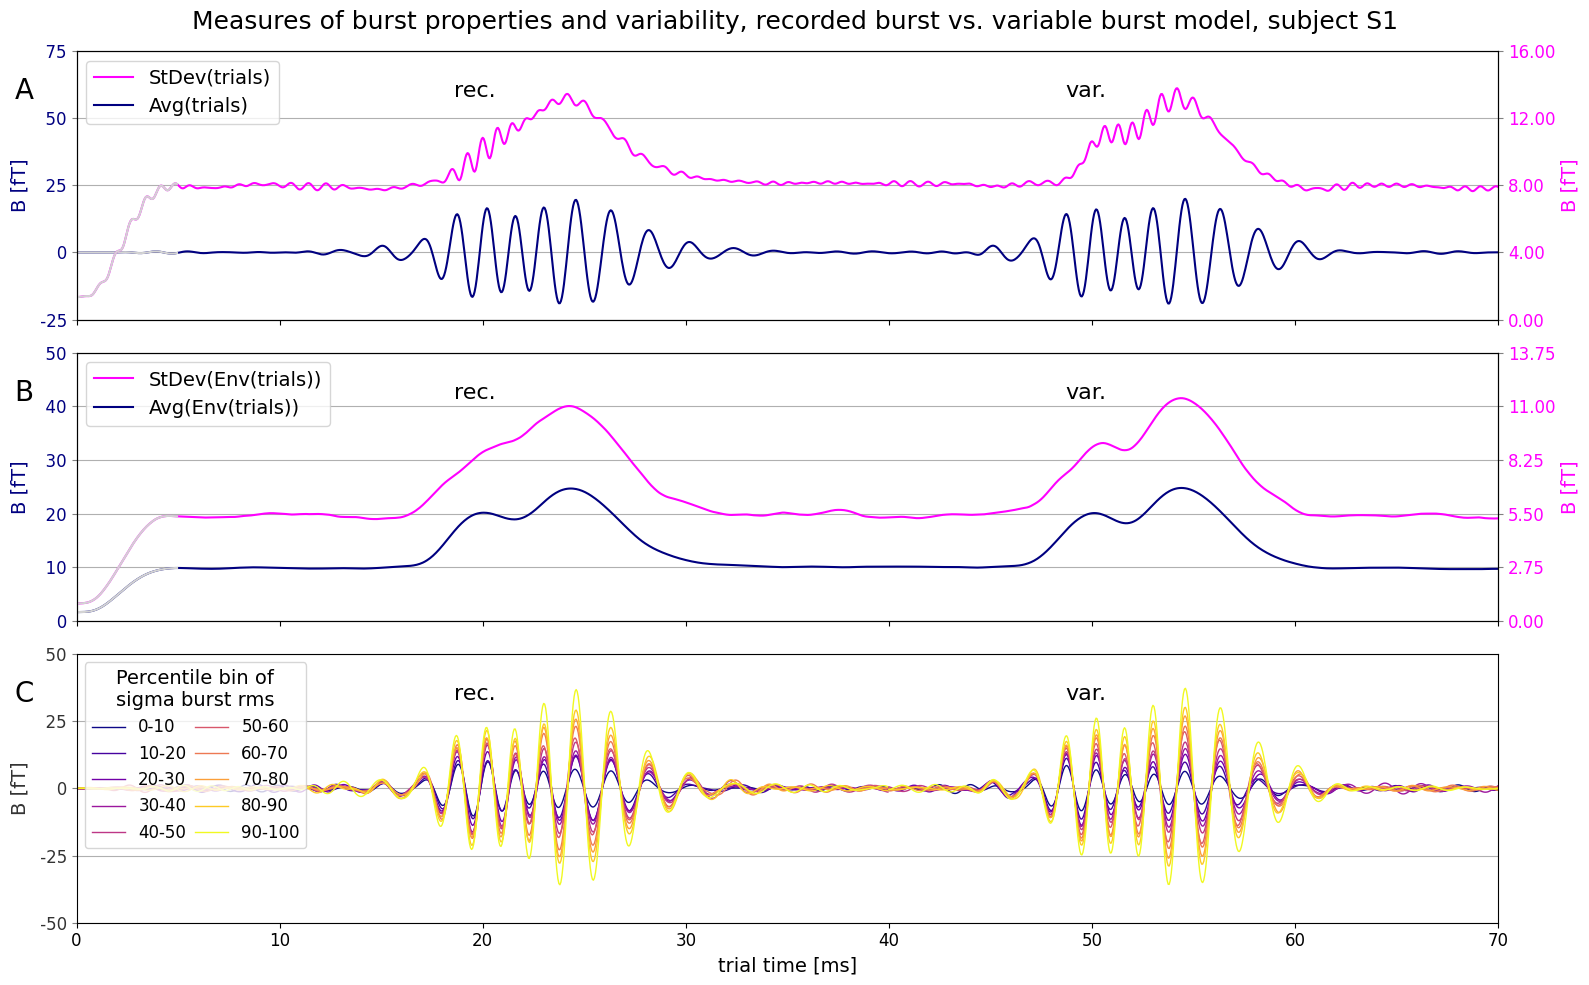

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(16, 10))

plt_header('Measures of burst properties and variability, recorded burst vs. variable burst model, subject %s'
           % subject, use_suptitle=True, fontsize=18)

data_t = data_t_medium_ms
data_y = sigma_sim_medium_trials.real.mean(-1)
axs[0].plot([], label='StDev(trials)', color='magenta')
axs[0].plot(data_t, data_y, label='Avg(trials)', color='navy')
axs[0].plot(data_t[:500], data_y[:500], color='lightgray')
axs[0].set_xlim(0, 70)
axs[0].tick_params(axis='x', labelbottom=False)
axs[0].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[0].set_ylim(-25, 75)
axs[0].grid(axis='y')
axs[0].yaxis.set_major_locator(plticker.MultipleLocator(25))
axs[0].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[0].tick_params(axis='y', color='grey', labelcolor='navy', labelsize=12)
axs[0].set_ylabel(meg_unit, color='navy', fontsize=14)
axs[0].legend(loc='upper left', fontsize=14)

axs2 = axs[0].twinx()
data_y = sigma_sim_medium_trials.real.std(-1)
std_baseline = np.round(data_y[-500:].mean()*2)/2
axs2.plot(data_t, data_y, color='magenta')
axs2.plot(data_t[:500], data_y[:500], color='lightgray')
ts = std_baseline/2
yticks = [0, ts, 2*ts, 3*ts, 4*ts]
axs2.set_ylim((yticks[0], yticks[-1]))
axs2.set_yticks(yticks) 
axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.2f'))
axs2.tick_params(axis='y', color='grey', labelcolor='magenta', labelsize=12)
axs2.set_ylabel(meg_unit, color='magenta', fontsize=14)

data_y = sigma_sim_medium_trials.__abs__().mean(-1)
axs[1].plot([], label='StDev(Env(trials))', color='magenta')
axs[1].plot(data_t, data_y, label='Avg(Env(trials))', color='navy')
axs[1].plot(data_t[:500], data_y[:500], color='lightgray')
axs[1].set_xlim(0, 70)
axs[1].tick_params(axis='x', labelbottom=False)
axs[1].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[1].set_ylim(0, 50)
axs[1].grid(axis='y')
axs[1].yaxis.set_major_locator(plticker.MultipleLocator(10))
axs[1].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[1].tick_params(axis='y', color='grey', labelcolor='navy', labelsize=12)
axs[1].set_ylabel(meg_unit, color='navy', fontsize=14)
axs[1].legend(loc='upper left', fontsize=14)

axs2 = axs[1].twinx()
data_y = sigma_sim_medium_trials.__abs__().std(-1)
std_baseline = np.round(data_y[-500:].mean()*2)/2
axs2.plot(data_t, data_y, color='magenta')
axs2.plot(data_t[:500], data_y[:500], color='lightgray')
ts = std_baseline/2
yticks = [0, ts, 2*ts, 3*ts, 4*ts, 5*ts]
axs2.set_ylim((yticks[0], yticks[-1]))
axs2.set_yticks(yticks) 
axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.2f'))
axs2.tick_params(axis='y', color='grey', labelcolor='magenta', labelsize=12)
axs2.set_ylabel(meg_unit, color='magenta', fontsize=14)


data = sigma_sim_medium_trials.real

sigma_trials_rms = np.sqrt(
    np.mean(data[burst_mt_smpl[0]:burst_mt_smpl[1]].real**2, axis=-2))

percentiled_signal = sigma_trials_rms
percentile_mask_list, trials_percentile_bins_names = percentile_sorting_mask(percentiled_signal)

I_mt_smpl = [0, np.nonzero(data_t_medium_ms == 40)[0][0]]
I_mt_smpl = np.array(I_mt_smpl)


colors = plt.cm.plasma(np.linspace(0, 1, len(percentile_mask_list)))
for k in range(len(percentile_mask_list)):
    data_y = data[:,percentile_mask_list[k]]
    data_y = np.mean(data_y, axis=-1)
    axs[2].plot(data_t[I_mt_smpl[0]:I_mt_smpl[1]], data_y[I_mt_smpl[0]:I_mt_smpl[1]],
                color=colors[k], label=trials_percentile_bins_names[k], linewidth=1)

sigma_sim_trials_rms = np.sqrt(
    np.mean(data[burst_sim_mt_smpl[0]:burst_sim_mt_smpl[1]].real**2, axis=-2))

percentiled_signal = sigma_sim_trials_rms
percentile_mask_list, trials_percentile_bins_names = percentile_sorting_mask(percentiled_signal)

II_mt_smpl = [np.nonzero(data_t_medium_ms == 40)[0][0], np.nonzero(data_t_medium_ms == 80)[0][0]]
II_mt_smpl = np.array(II_mt_smpl)


colors = plt.cm.plasma(np.linspace(0, 1, len(percentile_mask_list)))
for k in range(len(percentile_mask_list)):
    data_y = data[:,percentile_mask_list[k]]
    data_y = np.mean(data_y, axis=-1)
    axs[2].plot(data_t[II_mt_smpl[0]:II_mt_smpl[1]], data_y[II_mt_smpl[0]:II_mt_smpl[1]],
                color=colors[k], linewidth=1)

axs[2].set_xlim(0, 70)
axs[2].get_xaxis().set_major_locator(plticker.MultipleLocator(10))
axs[2].set_ylim(-50, 50)
axs[2].grid(axis='y')
axs[2].yaxis.set_major_locator(plticker.MultipleLocator(25))
axs[2].yaxis.set_major_formatter(plticker.FormatStrFormatter('%4d'))
axs[2].tick_params(axis='y', color='grey', labelcolor='0.2', labelsize=12)
axs[2].set_ylabel('B [fT]', color='0.2',fontsize=14)
axs[2].legend(title='Percentile bin of\nsigma burst rms', ncol=2, columnspacing=0.5, loc='upper left',
              title_fontsize=14, fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].set_xlabel('trial time [ms]', fontsize=14)

for i in range(3):
    axs[i].text(0.28, 0.85, 'rec.', fontsize=16, ha='center', va='center', transform=axs[i].transAxes)

    axs[i].text(0.71, 0.85, 'var.', fontsize=16, ha='center', va='center', transform=axs[i].transAxes)

axs[0].text(-0.037, 0.85, 'A', fontsize=20,
            ha='center', va='center', transform=axs[0].transAxes)
axs[1].text(-0.037, 0.85, 'B', fontsize=20,
            ha='center', va='center', transform=axs[1].transAxes)
axs[2].text(-0.037, 0.85, 'C', fontsize=20,
            ha='center', va='center', transform=axs[2].transAxes)

fig.tight_layout()
plt_show_save_fig()

In [18]:
sigma_sim_medium_trials_cmp = {}
sigma_bursts_sim_comp = {}

bmc = BurstModel(data_t_medium_ms, sigma_medium_trials, burst_win_ms, sigma_sim_offset_ms, srate, seed=2137)

func_vars_wrapper_out = bmc.calculate_model_output([10, 0, 0, 0, 0, 0])
sigma_sim_medium_trials_cmp['static'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['static'] = func_vars_wrapper_out[-2].numpy()

func_vars_wrapper_out = bmc.calculate_model_output([10, 0, 0, 0, 0.631, 0])
sigma_sim_medium_trials_cmp['ampl'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['ampl'] = func_vars_wrapper_out[-2].numpy()

func_vars_wrapper_out = bmc.calculate_model_output([10, 0, 0, 0, 0, 3.138])
sigma_sim_medium_trials_cmp['lat'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['lat'] = func_vars_wrapper_out[-2].numpy()

func_vars_wrapper_out = bmc.calculate_model_output([10, 0, 0, 0, 0.526, 2.334])
sigma_sim_medium_trials_cmp['ampl_lat'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['ampl_lat'] = func_vars_wrapper_out[-2].numpy()

func_vars_wrapper_out = bmc.calculate_model_output([1.171, 0.322, 0, 0, 0.595, 2.617])
sigma_sim_medium_trials_cmp['ampl_lat_split'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['ampl_lat_split'] = func_vars_wrapper_out[-2].numpy()

func_vars_wrapper_out = bmc.calculate_model_output([1.592, 0.339, 0.000, 1.561, 0.596, 2.596])
sigma_sim_medium_trials_cmp['full'] = func_vars_wrapper_out[-1].numpy()
sigma_bursts_sim_comp['full'] = func_vars_wrapper_out[-2].numpy()

--------------------
fig04.png


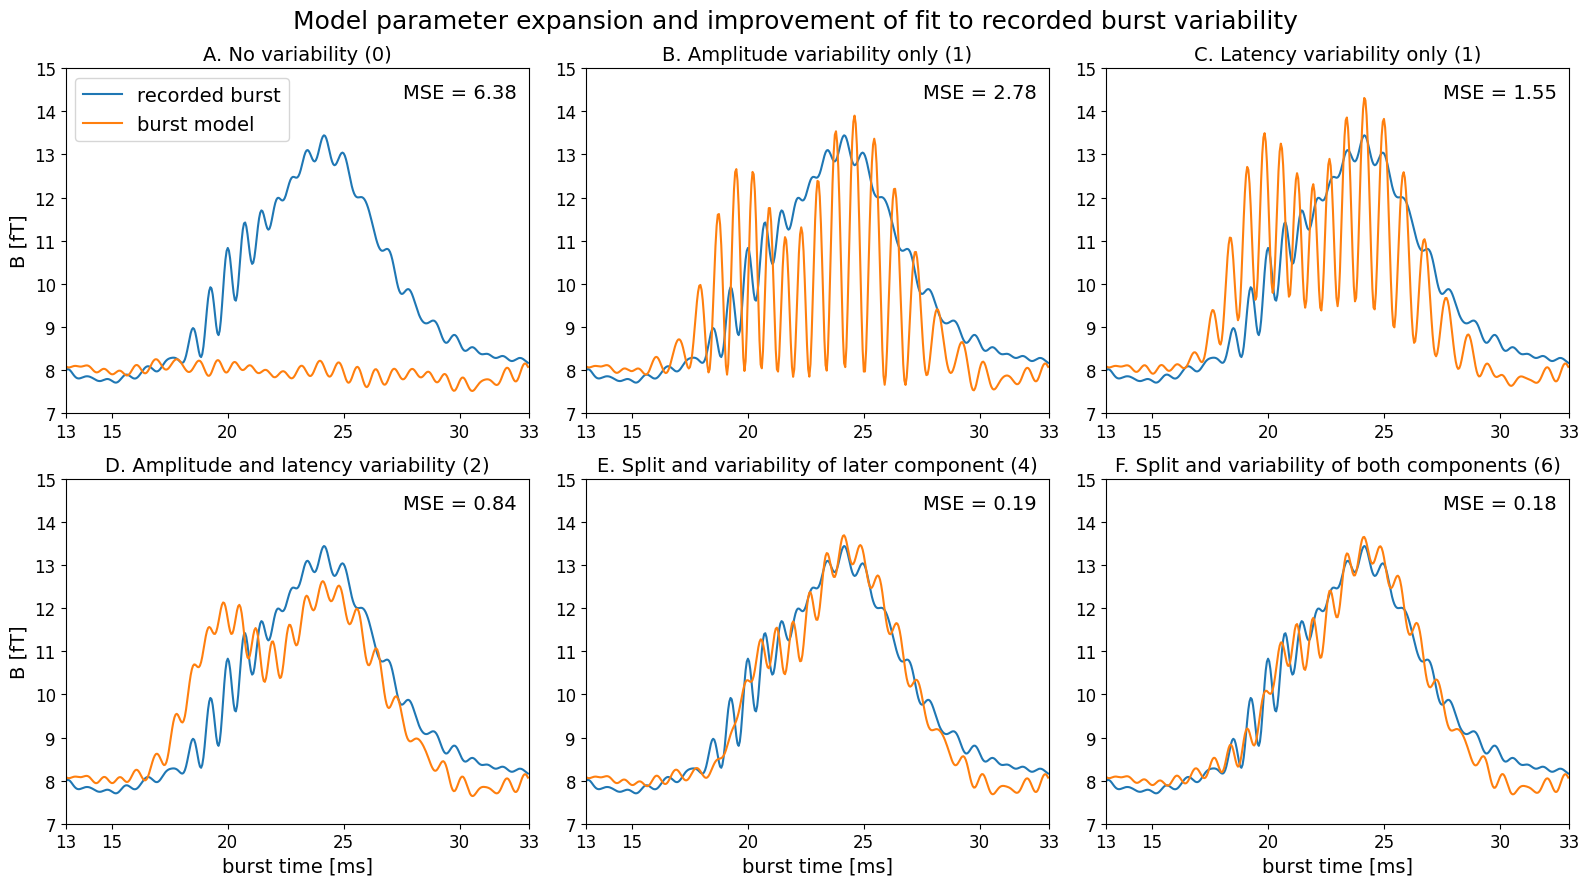

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(16, 9))
plt_header('Model parameter expansion and improvement of fit to recorded burst variability', use_suptitle=True, fontsize=18)

data_y = sigma_sim_medium_trials.real.std(-1)
data_y = data_y[burst_mt_smpl[0]:burst_mt_smpl[1]]
data_y_recorded = data_y
data_t = data_t_burst_ms

for k in range(6):

    if(k==0):
        i,j=0,0
        subplot_title='A. No variability (0)'
        model_name='static'
    elif(k==1):
        i,j=0,1
        subplot_title='B. Amplitude variability only (1)'
        model_name='ampl'
    elif(k==2):
        i,j=0,2
        subplot_title='C. Latency variability only (1)'
        model_name='lat'
    elif(k==3):
        i,j=1,0
        subplot_title='D. Amplitude and latency variability (2)'
        model_name='ampl_lat'
    elif(k==4):
        i,j=1,1
        subplot_title='E. Split and variability of later component (4)'
        model_name='ampl_lat_split'
    elif(k==5):
        i,j=1,2
        subplot_title='F. Split and variability of both components (6)'
        model_name='full'

    axs[i][j].set_title(subplot_title, fontsize=14)
    axs[i][j].plot(data_t, data_y_recorded, label='recorded burst')
    data_y = sigma_sim_medium_trials_cmp[model_name].real.std(-1)
    data_y = data_y[burst_sim_mt_smpl[0]:burst_sim_mt_smpl[1]]
    axs[i][j].plot(data_t, data_y, label='burst model')
    axs[i][j].set_ylim(7,15)
    axs[i][j].set_xlim(13,33)
    axs[i][j].set_xticks([13,15,20,25,30,33])
    axs[i][j].tick_params(labelsize=12)

    mse = ((data_y_recorded-data_y)**2).mean()
    axs[i][j].text(0.85, 0.93, 'MSE = %.2f' % mse, fontsize=14,
                ha='center', va='center', transform=axs[i][j].transAxes)

    if(k==0):
        axs[i][j].legend(loc='upper left', fontsize=14)
    if(j==0):
        axs[i][j].set_ylabel(meg_unit, fontsize=14)
    if(i==1):
        axs[i][j].set_xlabel('burst time [ms]', fontsize=14)
    

fig.tight_layout()
plt_show_save_fig()

--------------------
fig05.png


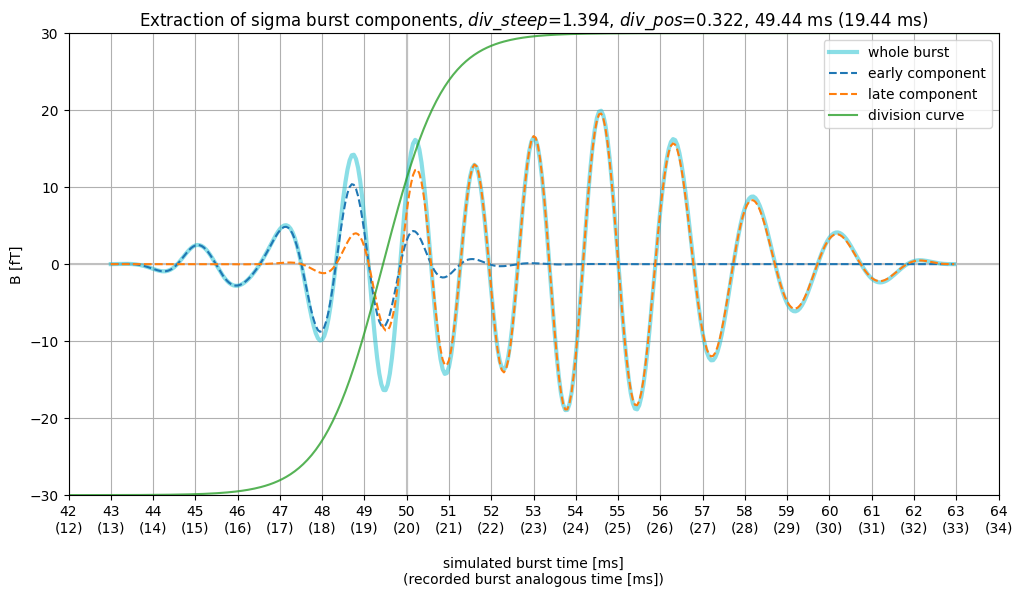

In [20]:
# plot extracted components
fig, axs = plt.subplots()

plt_header('Extraction of sigma burst components, ' \
'$\it{div\_steep}$=%.3f, $\it{div\_pos}$=%.3f, %.2f ms (%.2f ms)' %
(div_steep, div_pos, div_pos_ms+sigma_sim_offset_ms, div_pos_ms))

axs.axhline(0, color='silver')
axs.axvline(20, color='silver')
axs.plot(data_t_burst_ms, sigma_bursts_sim.real.mean(-1), label='whole burst', linewidth=3, alpha=0.5, c='tab:cyan')
axs.plot(data_t_burst_ms, earlier_comp_sigma_er.real, label='early component', linestyle='--')
axs.plot(data_t_burst_ms, later_comp_sigma_er.real, label='late component', linestyle='--')
division_curve_rescaled = 30*(2*division_curve-1)
axs.plot(data_t_medium_ms, division_curve_rescaled, alpha=0.8, label='division curve')


vmax=30
axs.set_ylim((-vmax,vmax))
axs.set_xlim((burst_win_ms[0], burst_win_ms[-1]))
axs.xaxis.set_major_locator(plticker.MultipleLocator(1))
ticks = axs.get_xticks().astype('int')
ticks_labels = [str(i+sigma_sim_offset_ms)+'\n('+str(i)+')' for i in ticks]
axs.set_xticks(ticks, ticks_labels)
axs.set_xlabel('\nsimulated burst time [ms]\n(recorded burst analogous time [ms])')
axs.set_ylabel(meg_unit)
axs.grid(visible=True)
axs.legend()

plt_show_save_fig()

--------------------
fig06.png


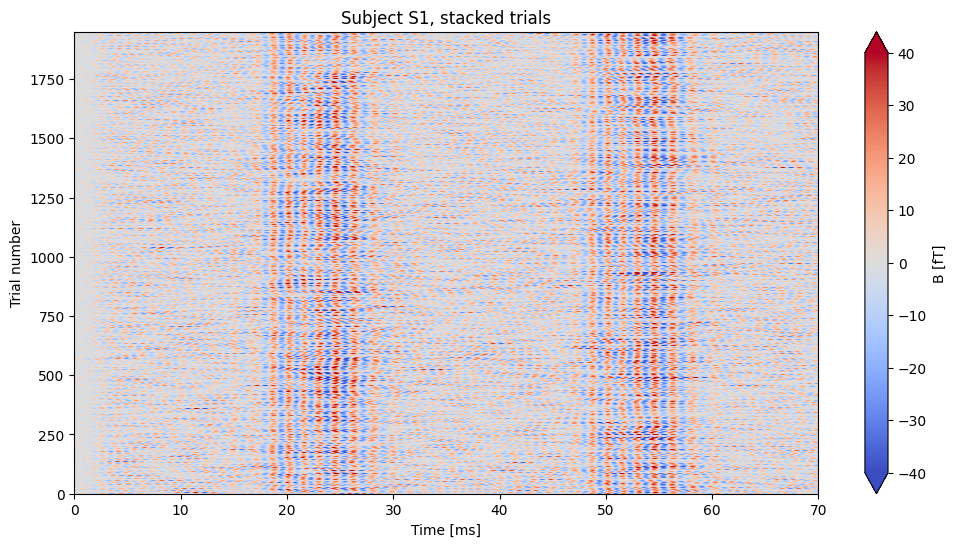

In [21]:
# plot sigma burst single trials stack on each other

plt_header('Subject S1, stacked trials')
data_t = data_t_medium_ms
data_y_input = sigma_sim_medium_trials
data_y = data_y_input.real

#limit = np.round(np.sqrt(np.mean(data_y**2))*3/10)*10
limit = 40

plt.pcolormesh(data_t, np.arange(len(data_y.T)), data_y.T,
            rasterized=True, shading='nearest', cmap='coolwarm', vmin=-limit, vmax=limit)
plt.ylabel('Trial number')
plt.xlabel('Time [ms]')
clb = plt.colorbar(extend='both')
clb.set_label(meg_unit)
plt.xlim(0,70)
plt.ylim(0, len(data_y.T))
plt_show_save_fig()

--------------------
fig07.png


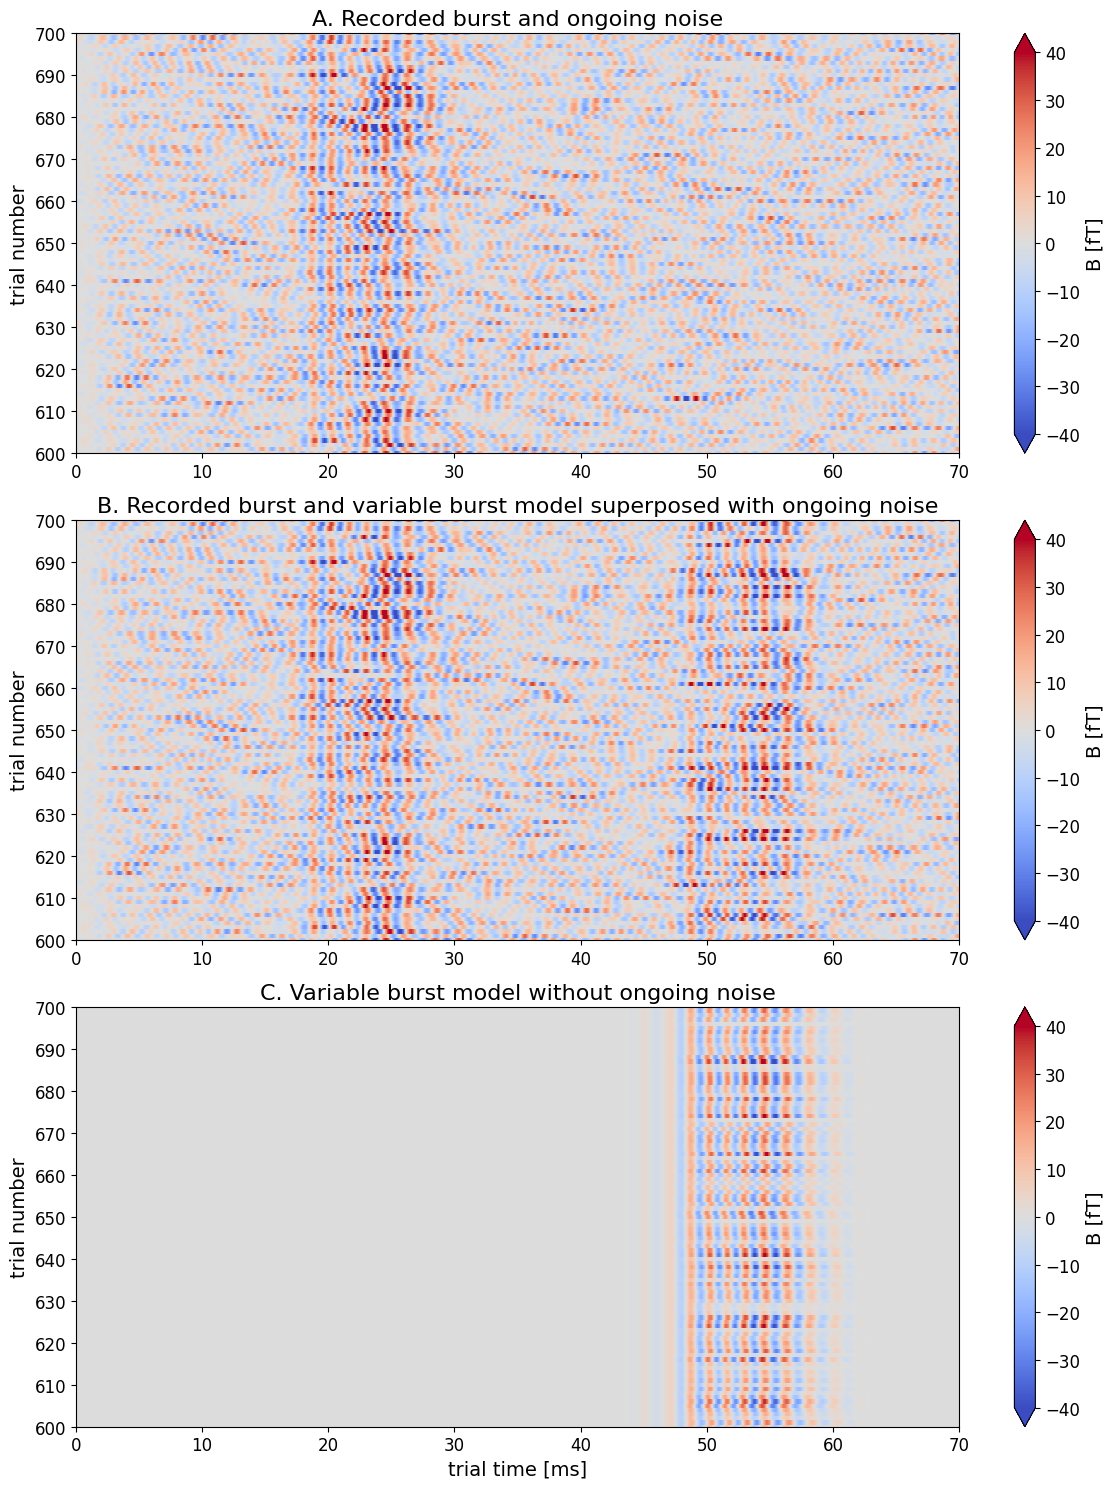

In [22]:
# plot sigma burst single trials stack on each other

fig, axs = plt.subplots(3, 1, figsize=(12, 15))

limit = 40

ylim_0 = 600
ylim_1 = 700

data_t = data_t_medium_ms
data_y = sigma_medium_trials.real

axs[0].set_title('A. Recorded burst and ongoing noise', fontsize=16)
img = axs[0].pcolormesh(data_t, np.arange(len(data_y.T)), data_y.T,
            rasterized=True, shading='nearest', cmap='coolwarm', vmin=-limit, vmax=limit)
axs[0].set_ylabel('trial number', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label(meg_unit, fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[0].yaxis.set_major_locator(plticker.MultipleLocator(10))
axs[0].set_ylim(ylim_0, ylim_1)
axs[0].set_xlim(0,70)
axs[0].tick_params(labelsize=12)

data_t = data_t_medium_ms
data_y = sigma_sim_medium_trials.real

axs[1].set_title('B. Recorded burst and variable burst model superposed with ongoing noise', fontsize=16)
img = axs[1].pcolormesh(data_t, np.arange(len(data_y.T)), data_y.T,
            rasterized=True, shading='nearest', cmap='coolwarm', vmin=-limit, vmax=limit)
axs[1].set_ylabel('trial number', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label(meg_unit, fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[1].yaxis.set_major_locator(plticker.MultipleLocator(10))
axs[1].set_ylim(ylim_0, ylim_1)
axs[1].set_xlim(0,70)
axs[1].tick_params(labelsize=12)

data_t = data_t_medium_ms
data_y = sigma_sim_medium_trials.real - sigma_medium_trials.real

axs[2].set_title('C. Variable burst model without ongoing noise', fontsize=16)
img = axs[2].pcolormesh(data_t, np.arange(len(data_y.T)), data_y.T,
            rasterized=True, shading='nearest', cmap='coolwarm', vmin=-limit, vmax=limit)
axs[2].set_ylabel('trial number', fontsize=14)
axs[2].set_xlabel('trial time [ms]', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label(meg_unit, fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[2].yaxis.set_major_locator(plticker.MultipleLocator(10))
axs[2].set_ylim(ylim_0, ylim_1)
axs[2].set_xlim(0,70)
axs[2].tick_params(labelsize=12)

fig.tight_layout()
plt_show_save_fig()